<a href="https://colab.research.google.com/github/mervegoktanir/DSA210-Project/blob/main/dsa210project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install pytrends pandas matplotlib seaborn scipy

In [16]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, f_oneway

### Data Loading Note

The datasets are loaded directly from the GitHub repository using raw CSV links. This makes the notebook reproducible and easy to run without requiring manual file uploads. Live Google Trends requests were avoided because they may fail due to request limits.

In [17]:
trends_data = pd.read_csv(
    "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/google_trends_matcha.csv"
)

trends_data["date"] = pd.to_datetime(trends_data["date"])

print("Google Trends 12-month data loaded from existing CSV.")
print("Shape:", trends_data.shape)

trends_data.head()

Google Trends 12-month data loaded from existing CSV.
Shape: (53, 4)


,date,matcha,matcha latte,isPartial
0,2025-04-13,71,7,False
1,2025-04-20,73,7,False
2,2025-04-27,84,7,False
3,2025-05-04,77,8,False
4,2025-05-11,73,7,False


In [18]:
trends_data.to_csv("google_trends_matcha.csv", index=False)
print("Google Trends verisi kaydedildi.")

Google Trends verisi kaydedildi.


In [19]:
print("Veri boyutu:", trends_data.shape)
trends_data.head(10)

Veri boyutu: (53, 4)


,date,matcha,matcha latte,isPartial
0,2025-04-13,71,7,False
1,2025-04-20,73,7,False
2,2025-04-27,84,7,False
3,2025-05-04,77,8,False
4,2025-05-11,73,7,False
5,2025-05-18,77,7,False
6,2025-05-25,78,7,False
7,2025-06-01,81,7,False
8,2025-06-08,79,7,False
9,2025-06-15,75,6,False


In [20]:
trends_data["date"] = pd.to_datetime(trends_data["date"])
trends_data.dtypes

,0
date,datetime64[ns]
matcha,int64
matcha latte,int64
isPartial,bool


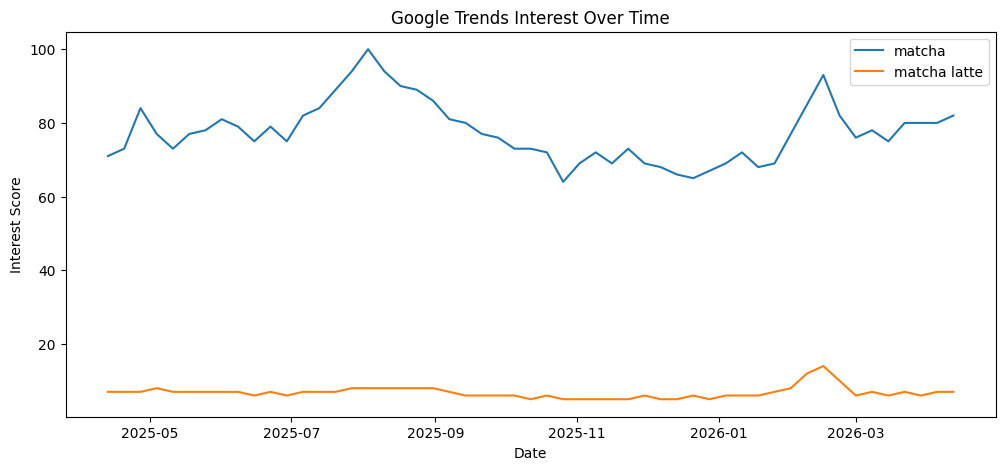

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data["date"], trends_data["matcha"], label="matcha")
plt.plot(trends_data["date"], trends_data["matcha latte"], label="matcha latte")

plt.title("Google Trends Interest Over Time")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

In [22]:
trends_data_5y = pd.read_csv(
    "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/google_trends_matcha_5y.csv"
)

trends_data_5y["date"] = pd.to_datetime(trends_data_5y["date"])

print("Google Trends 5-year data loaded from existing CSV.")
print("Shape:", trends_data_5y.shape)

trends_data_5y.head()

Google Trends 5-year data loaded from existing CSV.
Shape: (262, 4)


,date,matcha,matcha latte,isPartial
0,2021-04-11,21,2,False
1,2021-04-18,20,2,False
2,2021-04-25,21,2,False
3,2021-05-02,21,2,False
4,2021-05-09,19,2,False


In [23]:
trends_data_5y.to_csv("google_trends_matcha_5y.csv", index=False)
print("5 yıllık Google Trends verisi kaydedildi.")

5 yıllık Google Trends verisi kaydedildi.


In [24]:
trends_data_5y["date"] = pd.to_datetime(trends_data_5y["date"])
trends_data_5y.dtypes

,0
date,datetime64[ns]
matcha,int64
matcha latte,int64
isPartial,bool


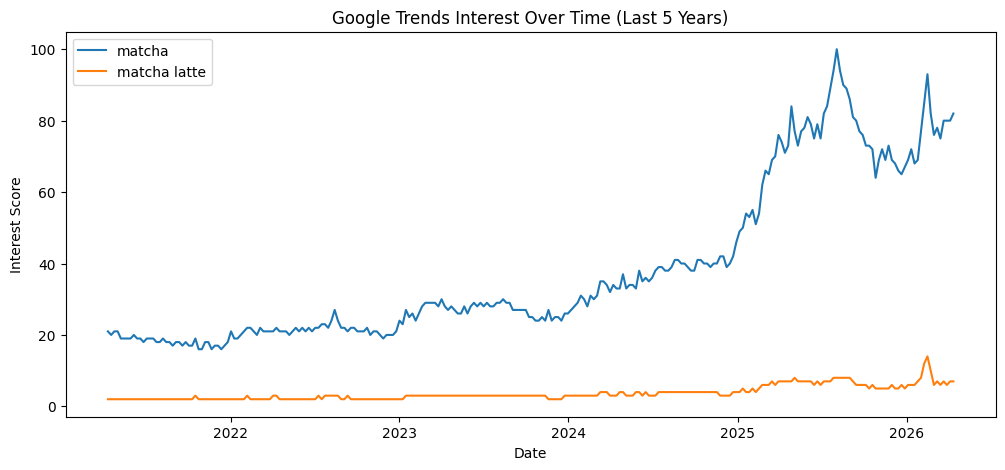

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data_5y["date"], trends_data_5y["matcha"], label="matcha")
plt.plot(trends_data_5y["date"], trends_data_5y["matcha latte"], label="matcha latte")

plt.title("Google Trends Interest Over Time (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

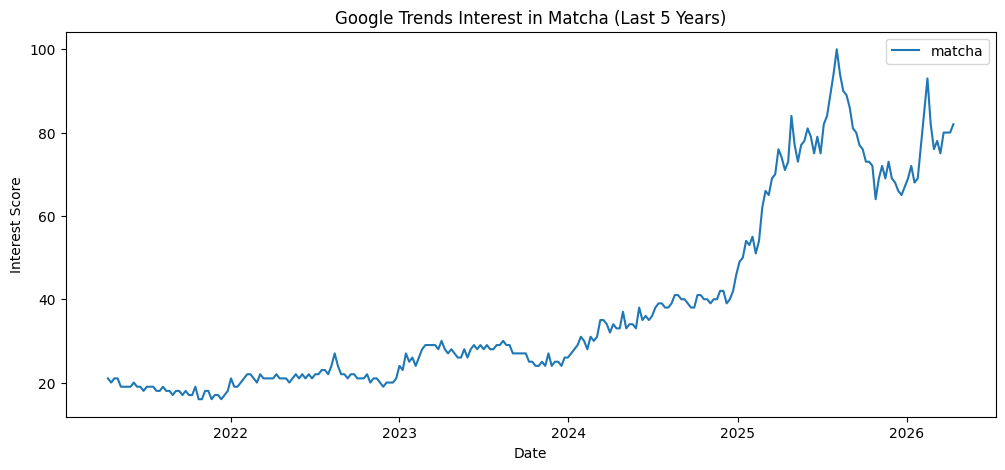

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data_5y["date"], trends_data_5y["matcha"], label="matcha")

plt.title("Google Trends Interest in Matcha (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

In [27]:
real_data = [
    ["Carrington Farms Organic Matcha Green Tea Powder, 3.5oz", 8.74, 4.3, 473, "powder", "Walmart", "2026-04-13"],
    ["Morning Made Ceremonial Grade Organic Matcha Latte Powder, Vanilla, 10 pack (0.18oz ea)", 8.98, 4.3, 227, "latte_mix", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Ceremonial Grade Matcha Powder, Barista Edition, 1.06 oz Tin", 19.99, 4.6, 907, "ceremonial", "Walmart", "2026-04-13"],
    ["Jade Leaf Matcha, Organic Japanese Culinary Matcha, Powdered Tea, 0.7 Oz", 8.64, 4.5, 1699, "powder", "Walmart", "2026-04-13"],
    ["Jade Leaf Matcha, Organic Japanese Matcha Latte Mix, Powdered Tea, 3.5 Oz", 8.64, 4.4, 1847, "latte_mix", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Matcha Latte Mix, Original, Dairy-Free Matcha Green Tea Powder, 17.6 oz Tub", 24.79, 4.6, 611, "latte_mix", "Walmart", "2026-04-13"],
    ["Terrasoul Superfoods Organic Matcha Green Tea (Ceremonial Grade in Miron Glass), 4.24 Oz / 120g (2.12 Oz 2-Pack)", 37.99, 4.9, 78, "ceremonial", "Walmart", "2026-04-13"],
    ["MatchAiA USDA-Certified Organic Matcha, 100% Pure Green Tea Powder, Premium Culinary Grade for Lattes, Smoothies, Desserts and Baking, Sugar Free, Gluten Free (60g / 2.1oz Pouch)", 8.95, 4.6, 19, "powder", "Walmart", "2026-04-13"],
    ["Everyday Matcha 100% Japanese Green Tea Powder, 12 Ounce", 33.00, 4.8, 12, "powder", "Walmart", "2026-04-13"],
    ["uVernal Organic Matcha Green Tea Powder - 100% Pure Matcha for Smoothies Latte and Baking Easy to Mix - 4oz", 14.99, 4.8, 1029, "powder", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Matcha Latte Mix, Original, Dairy-Free Matcha Green Tea Powder, 17.6 oz Tub", 30.99, 4.6, 628, "latte_mix", "Walmart", "2026-04-13"],
    ["Melting Forest Mushroom Matcha Powder with Reishi, Lion’s Mane, Organic Adaptogen Blend, GMO-Free, 30 Count", 14.99, 5.0, 1, "powder", "Walmart", "2026-04-13"]
]

products = pd.DataFrame(real_data,  columns=[
    "product_name",
    "price",
    "rating",
    "review_count",
    "category",
    "source",
    "date_collected"
])

products

,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13
5,"Jade Leaf Organic Matcha Latte Mix, Original, ...",24.79,4.6,611,latte_mix,Walmart,2026-04-13
6,Terrasoul Superfoods Organic Matcha Green Tea ...,37.99,4.9,78,ceremonial,Walmart,2026-04-13
7,"MatchAiA USDA-Certified Organic Matcha, 100% P...",8.95,4.6,19,powder,Walmart,2026-04-13
8,Everyday Matcha 100% Japanese Green Tea Powder...,33.00,4.8,12,powder,Walmart,2026-04-13
9,uVernal Organic Matcha Green Tea Powder - 100%...,14.99,4.8,1029,powder,Walmart,2026-04-13


In [28]:
products.to_csv("matcha_products_real.csv", index=False)
print("Gerçek ürün verisi kaydedildi.")

Gerçek ürün verisi kaydedildi.


In [29]:
print("Boyut:", products.shape)
print(products.dtypes)
products.head()

Boyut: (12, 7)
product_name       object
price             float64
rating            float64
review_count        int64
category           object
source             object
date_collected     object
dtype: object


,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13


In [30]:
products["price"] = pd.to_numeric(products["price"], errors="coerce")
products["rating"] = pd.to_numeric(products["rating"], errors="coerce")
products["review_count"] = pd.to_numeric(products["review_count"], errors="coerce")
products["date_collected"] = pd.to_datetime(products["date_collected"])

products = products.drop_duplicates()
products = products.dropna()

print("Temizlenmiş boyut:", products.shape)
products

Temizlenmiş boyut: (12, 7)


,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13
5,"Jade Leaf Organic Matcha Latte Mix, Original, ...",24.79,4.6,611,latte_mix,Walmart,2026-04-13
6,Terrasoul Superfoods Organic Matcha Green Tea ...,37.99,4.9,78,ceremonial,Walmart,2026-04-13
7,"MatchAiA USDA-Certified Organic Matcha, 100% P...",8.95,4.6,19,powder,Walmart,2026-04-13
8,Everyday Matcha 100% Japanese Green Tea Powder...,33.00,4.8,12,powder,Walmart,2026-04-13
9,uVernal Organic Matcha Green Tea Powder - 100%...,14.99,4.8,1029,powder,Walmart,2026-04-13


In [31]:
products.describe()

,price,rating,review_count,date_collected
count,12.000000,12.000000,12.000000,12
mean,18.390833,4.616667,627.583333,2026-04-13 00:00:00
min,8.640000,4.300000,1.000000,2026-04-13 00:00:00
25%,8.897500,4.475000,63.250000,2026-04-13 00:00:00
50%,14.990000,4.600000,542.000000,2026-04-13 00:00:00
75%,26.340000,4.800000,937.500000,2026-04-13 00:00:00
max,37.990000,5.000000,1847.000000,2026-04-13 00:00:00
std,10.803709,0.224958,639.795629,NaN


In [32]:
products["category"].value_counts()

,count
category,
powder,6
latte_mix,4
ceremonial,2


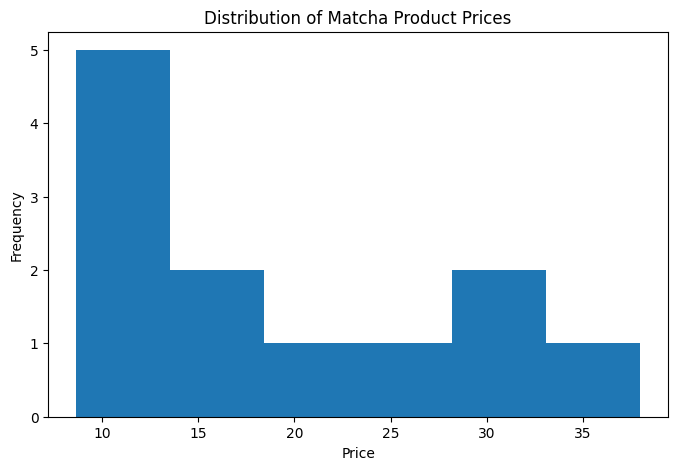

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(products["price"], bins=6)
plt.title("Distribution of Matcha Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

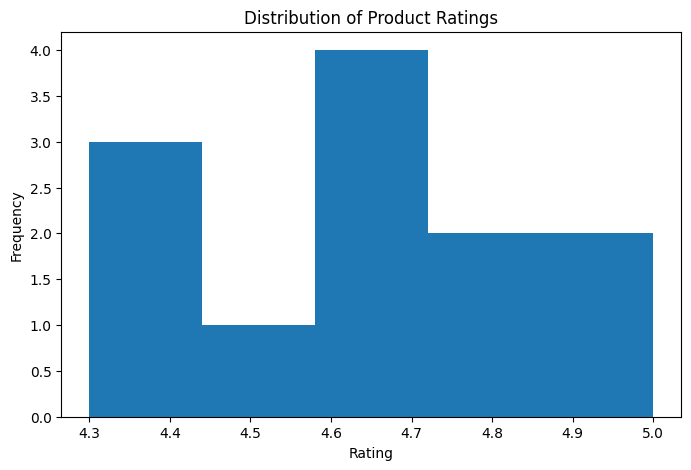

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(products["rating"], bins=5)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

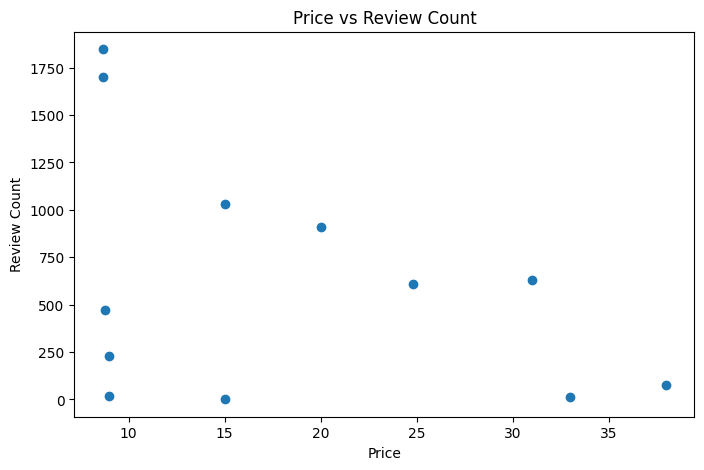

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(products["price"], products["review_count"])
plt.title("Price vs Review Count")
plt.xlabel("Price")
plt.ylabel("Review Count")
plt.show()

In [36]:
corr, p_value = spearmanr(products["price"], products["review_count"])

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: -0.42807281055172736
p-value: 0.16505280636941294


In [37]:
category_summary = products.groupby("category")[["price", "rating", "review_count"]].mean()
category_summary

,price,rating,review_count
category,,,
ceremonial,28.990,4.750000,492.500000
latte_mix,18.350,4.475000,828.250000
powder,14.885,4.666667,538.833333


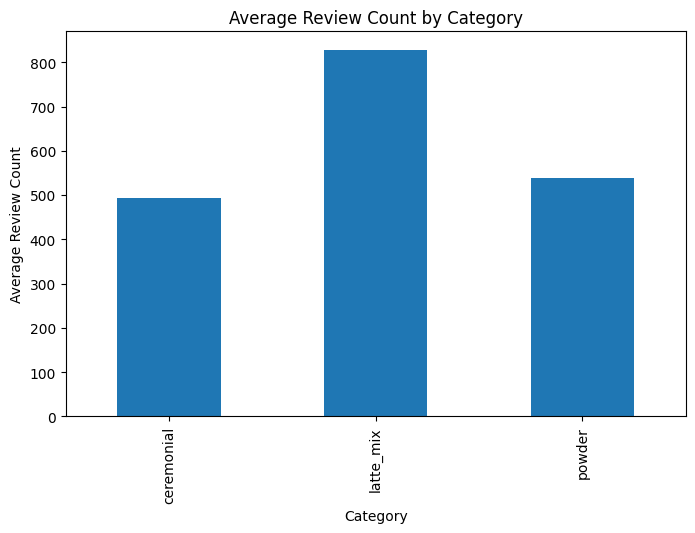

In [38]:
category_summary["review_count"].plot(kind="bar", figsize=(8,5))
plt.title("Average Review Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Review Count")
plt.show()

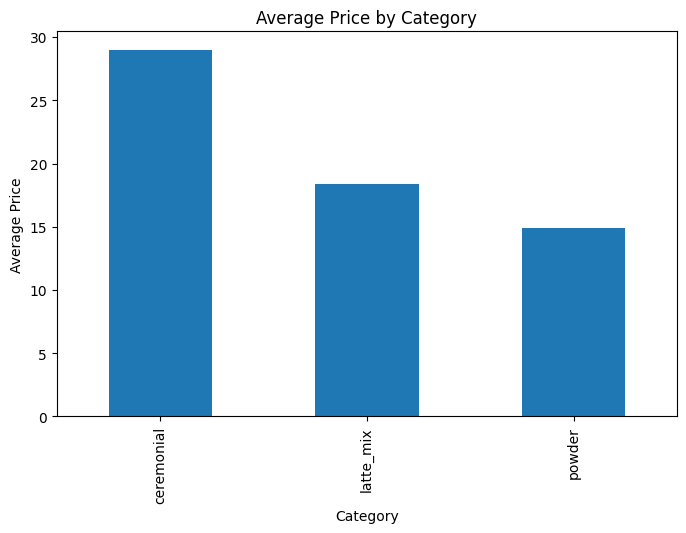

In [39]:
category_summary["price"].plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

In [40]:
from scipy.stats import kruskal

In [41]:
groups = [group["review_count"].values for name, group in products.groupby("category")]

stat, p_value_kw = kruskal(*groups)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p_value_kw)

Kruskal-Wallis statistic: 1.1538461538461533
p-value: 0.5616237838971457


In [42]:
products.to_csv("matcha_products_clean.csv", index=False)
print("Temiz ürün verisi kaydedildi.")

Temiz ürün verisi kaydedildi.


### Google Trends Analysis
The 5-year Google Trends data suggests that online interest in matcha has increased over time, especially from 2024 onward.

### Product Data Collection
Product-level data was collected from publicly available retail pages. The dataset includes product name, price, rating, review count, category, source, and collection date.

### Exploratory Data Analysis
The dataset shows variation in price, rating, and review count across product categories. The current sample includes powder, latte mix, and ceremonial products.

### Hypothesis Test 1: Price vs Review Count
A Spearman correlation test was used to examine the relationship between price and review count. The correlation coefficient is negative, suggesting a possible inverse relationship, but the p-value is greater than 0.05. Therefore, the result is not statistically significant.

### Hypothesis Test 2: Category Differences in Review Count
A Kruskal-Wallis test was used to examine whether review counts differ across product categories. The p-value is greater than 0.05, so the current sample does not provide strong evidence of a statistically significant difference between categories.

### Limitation
The current product dataset is relatively small and represents a snapshot collected on a single date. Therefore, the results should be interpreted cautiously.

## Extended Hypothesis Testing

Based on the project feedback, the hypothesis testing section was extended. In this section, each test includes the research question, null and alternative hypotheses, significance level, test choice, p-value, decision, and interpretation.

In [43]:
from scipy.stats import spearmanr, kruskal, mannwhitneyu
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

# Reload cleaned datasets to make this section self-contained
trends_url = "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/google_trends_matcha_5y.csv"
products_url = "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/matcha_products_clean.csv"

trends_ht = pd.read_csv(trends_url)
products_ht = pd.read_csv(products_url)

trends_ht["date"] = pd.to_datetime(trends_ht["date"])
products_ht["date_collected"] = pd.to_datetime(products_ht["date_collected"])

# Ensure numeric columns
products_ht["price"] = pd.to_numeric(products_ht["price"], errors="coerce")
products_ht["rating"] = pd.to_numeric(products_ht["rating"], errors="coerce")
products_ht["review_count"] = pd.to_numeric(products_ht["review_count"], errors="coerce")

alpha = 0.05

def decision_text(p_value):
    if p_value < alpha:
        return "Reject H0"
    else:
        return "Fail to reject H0"

def significance_text(p_value):
    if p_value < alpha:
        return "statistically significant"
    else:
        return "not statistically significant"

results = []

# Hypothesis Test 1: Price vs Review Count
test1_data = products_ht[["price", "review_count"]].dropna()
stat1, p1 = spearmanr(test1_data["price"], test1_data["review_count"])

results.append({
    "Test": "Spearman Correlation",
    "Research Question": "Is there a monotonic relationship between product price and review count?",
    "H0": "There is no monotonic relationship between price and review count.",
    "H1": "There is a monotonic relationship between price and review count.",
    "Variables": "price, review_count",
    "Test Statistic": stat1,
    "p-value": p1,
    "Decision": decision_text(p1),
    "Interpretation": f"The relationship between price and review count is {significance_text(p1)} at α = 0.05."
})

# Hypothesis Test 2: Category Differences in Review Count
groups_review = [
    group["review_count"].dropna().values
    for name, group in products_ht.groupby("category")
    if len(group["review_count"].dropna()) > 0
]

stat2, p2 = kruskal(*groups_review)

results.append({
    "Test": "Kruskal-Wallis Test",
    "Research Question": "Do review counts differ across product categories?",
    "H0": "The distribution of review counts is the same across product categories.",
    "H1": "At least one product category has a different review count distribution.",
    "Variables": "category, review_count",
    "Test Statistic": stat2,
    "p-value": p2,
    "Decision": decision_text(p2),
    "Interpretation": f"The difference in review counts across product categories is {significance_text(p2)} at α = 0.05."
})

# Hypothesis Test 3: Matcha Interest vs Matcha Latte Interest
test3_data = trends_ht[["matcha", "matcha latte"]].dropna()
stat3, p3 = spearmanr(test3_data["matcha"], test3_data["matcha latte"])

results.append({
    "Test": "Spearman Correlation",
    "Research Question": "Is there a monotonic relationship between search interest in matcha and matcha latte?",
    "H0": "There is no monotonic relationship between matcha interest and matcha latte interest.",
    "H1": "There is a monotonic relationship between matcha interest and matcha latte interest.",
    "Variables": "matcha, matcha latte",
    "Test Statistic": stat3,
    "p-value": p3,
    "Decision": decision_text(p3),
    "Interpretation": f"The relationship between matcha and matcha latte search interest is {significance_text(p3)} at α = 0.05."
})

# Hypothesis Test 4: High vs Low Matcha Latte Interest
median_latte = trends_ht["matcha latte"].median()

high_latte_group = trends_ht[trends_ht["matcha latte"] > median_latte]["matcha"].dropna()
low_latte_group = trends_ht[trends_ht["matcha latte"] <= median_latte]["matcha"].dropna()

stat4, p4 = mannwhitneyu(high_latte_group, low_latte_group, alternative="two-sided")

results.append({
    "Test": "Mann-Whitney U Test",
    "Research Question": "Is matcha interest different when matcha latte interest is high versus low?",
    "H0": "The distribution of matcha interest is the same in high and low matcha latte interest periods.",
    "H1": "The distribution of matcha interest is different in high and low matcha latte interest periods.",
    "Variables": "matcha, matcha latte group",
    "Test Statistic": stat4,
    "p-value": p4,
    "Decision": decision_text(p4),
    "Interpretation": f"The difference in matcha interest between high and low matcha latte interest periods is {significance_text(p4)} at α = 0.05."
})

hypothesis_results = pd.DataFrame(results)

display(hypothesis_results)

,Test,Research Question,H0,H1,Variables,Test Statistic,p-value,Decision,Interpretation
0,Spearman Correlation,Is there a monotonic relationship between prod...,There is no monotonic relationship between pri...,There is a monotonic relationship between pric...,"price, review_count",-0.428073,1.650528e-01,Fail to reject H0,The relationship between price and review coun...
1,Kruskal-Wallis Test,Do review counts differ across product categor...,The distribution of review counts is the same ...,At least one product category has a different ...,"category, review_count",1.153846,5.616238e-01,Fail to reject H0,The difference in review counts across product...
2,Spearman Correlation,Is there a monotonic relationship between sear...,There is no monotonic relationship between mat...,There is a monotonic relationship between matc...,"matcha, matcha latte",0.946539,9.253263e-130,Reject H0,The relationship between matcha and matcha lat...
3,Mann-Whitney U Test,Is matcha interest different when matcha latte...,The distribution of matcha interest is the sam...,The distribution of matcha interest is differe...,"matcha, matcha latte group",15814.000000,2.772540e-40,Reject H0,The difference in matcha interest between high...


### Hypothesis Testing Interpretation

The hypothesis testing section was expanded to include both product-level and Google Trends-based statistical tests. Since the product dataset is relatively small and some variables may not satisfy normality assumptions, non-parametric tests were preferred where appropriate.

The Spearman correlation tests were used because they measure monotonic relationships without requiring a strictly linear relationship or normally distributed variables. The Kruskal-Wallis test was used to compare review counts across multiple product categories. The Mann-Whitney U test was used to compare matcha search interest between periods with high and low matcha latte search interest.

These tests provide a more complete statistical analysis by examining both product demand indicators and online search behavior. The results should still be interpreted cautiously because the product dataset has a limited number of observations, while the Google Trends dataset provides a stronger time-based sample.%

### Detailed Hypothesis Test Decisions

The first test examined the relationship between product price and review count using Spearman correlation. The p-value was greater than 0.05, so the null hypothesis could not be rejected. This means that the current product dataset does not provide statistically significant evidence of a monotonic relationship between price and review count.

The second test compared review counts across product categories using the Kruskal-Wallis test. Since the p-value was also greater than 0.05, the null hypothesis could not be rejected. Therefore, the current sample does not show a statistically significant difference in review count distributions across product categories.

The third test examined the relationship between Google Trends interest in "matcha" and "matcha latte". The p-value was far below 0.05, so the null hypothesis was rejected. This indicates a statistically significant and strong positive monotonic relationship between matcha search interest and matcha latte search interest.

The fourth test compared matcha search interest between periods with high and low matcha latte interest using the Mann-Whitney U test. Since the p-value was far below 0.05, the null hypothesis was rejected. This suggests that matcha interest is significantly different between high and low matcha latte interest periods.

Overall, the product-level tests did not show statistically significant results, likely because the product dataset is small. However, the Google Trends-based tests showed strong statistical significance, which supports the idea that online search behavior provides a meaningful signal for matcha-related demand and interest.

## Milestone 2: Machine Learning Methods

In [44]:
import pandas as pd
import numpy as np

trends_url = "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/google_trends_matcha_5y.csv"
products_url = "https://raw.githubusercontent.com/mervegoktanir/DSA210-Project/main/matcha_products_clean.csv"

trends_df = pd.read_csv(trends_url)
products_df = pd.read_csv(products_url)

trends_df["date"] = pd.to_datetime(trends_df["date"])
products_df["date_collected"] = pd.to_datetime(products_df["date_collected"])

print("Google Trends data shape:", trends_df.shape)
print("Product data shape:", products_df.shape)

print("\nGoogle Trends columns:")
print(trends_df.columns)

print("\nProduct data columns:")
print(products_df.columns)

display(trends_df.head())
display(products_df.head())

Google Trends data shape: (262, 4)
Product data shape: (12, 7)

Google Trends columns:
Index(['date', 'matcha', 'matcha latte', 'isPartial'], dtype='object')

Product data columns:
Index(['product_name', 'price', 'rating', 'review_count', 'category', 'source',
       'date_collected'],
      dtype='object')


,date,matcha,matcha latte,isPartial
0,2021-04-11,21,2,False
1,2021-04-18,20,2,False
2,2021-04-25,21,2,False
3,2021-05-02,21,2,False
4,2021-05-09,19,2,False


,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13


### Machine Learning Objective

The goal of this milestone is to apply machine learning methods to the dataset. Since the Google Trends dataset contains a larger time-based sample than the product dataset, the main machine learning task is designed as a regression problem.

The target variable is the Google Trends interest score for "matcha". The model aims to predict matcha search interest using time-based features and related search interest variables such as "matcha latte".

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Copy data
ml_df = trends_df.copy()

# Sort by date
ml_df = ml_df.sort_values("date").reset_index(drop=True)

# Create time-based features
ml_df["year"] = ml_df["date"].dt.year
ml_df["month"] = ml_df["date"].dt.month
ml_df["weekofyear"] = ml_df["date"].dt.isocalendar().week.astype(int)
ml_df["time_index"] = range(len(ml_df))

# Lag and rolling features for matcha interest
ml_df["matcha_lag_1"] = ml_df["matcha"].shift(1)
ml_df["matcha_lag_4"] = ml_df["matcha"].shift(4)
ml_df["matcha_rolling_4"] = ml_df["matcha"].rolling(window=4).mean()
ml_df["matcha_rolling_12"] = ml_df["matcha"].rolling(window=12).mean()

# Drop missing rows created by lag and rolling operations
ml_df = ml_df.dropna().reset_index(drop=True)

# Features and target
feature_cols = [
    "time_index",
    "year",
    "month",
    "weekofyear",
    "matcha latte",
    "matcha_lag_1",
    "matcha_lag_4",
    "matcha_rolling_4",
    "matcha_rolling_12"
]

X = ml_df[feature_cols]
y = ml_df["matcha"]

# Time-based train-test split
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (200, 9)
Test set size: (51, 9)


In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.837540,3.543059,0.809185
1,Ridge Regression,2.841823,3.535231,0.810028
2,Random Forest Regressor,7.325098,9.748462,-0.444532


### Best Model Visualization

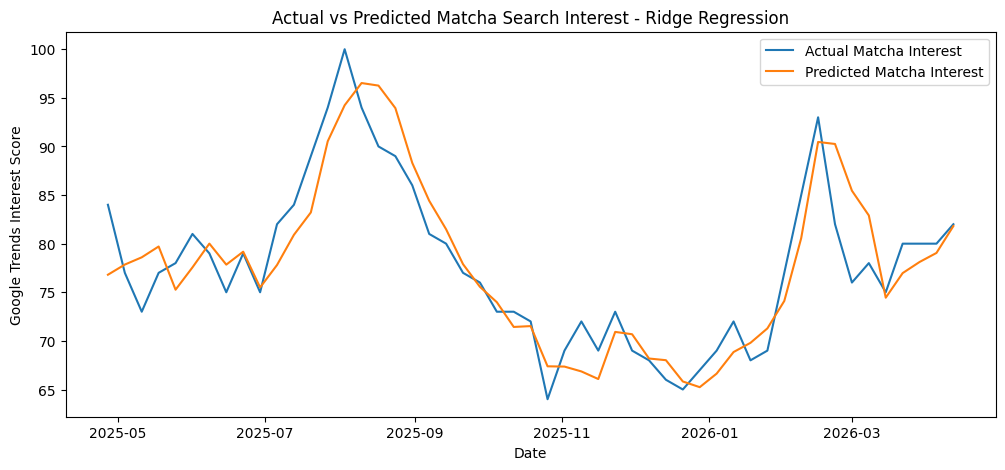

Best Model: Ridge Regression
MAE: 2.8418225911328685
RMSE: 3.5352309345072293
R2 Score: 0.8100276538767598


In [47]:
best_model = Ridge(alpha=1.0)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(ml_df["date"].iloc[split_index:], y_test.values, label="Actual Matcha Interest")
plt.plot(ml_df["date"].iloc[split_index:], y_pred_best, label="Predicted Matcha Interest")
plt.title("Actual vs Predicted Matcha Search Interest - Ridge Regression")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest Score")
plt.legend()
plt.show()

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Best Model: Ridge Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

,Feature,Coefficient
7,matcha_rolling_4,1.293380
4,matcha latte,0.885429
1,year,0.490917
6,matcha_lag_4,-0.194489
2,month,-0.182750
8,matcha_rolling_12,-0.106129
5,matcha_lag_1,-0.075205
3,weekofyear,0.046864
0,time_index,-0.005398


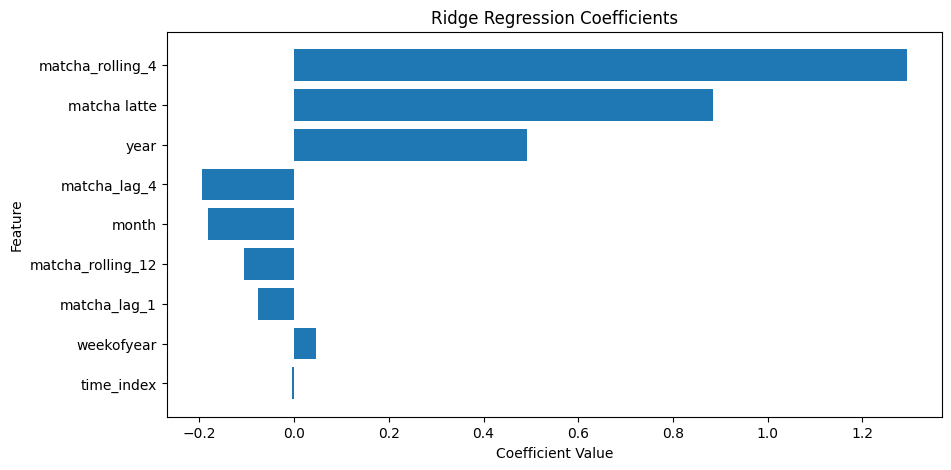

In [48]:
ridge_coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": best_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

display(ridge_coefficients)

plt.figure(figsize=(10, 5))
plt.barh(ridge_coefficients["Feature"], ridge_coefficients["Coefficient"])
plt.title("Ridge Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Machine Learning Results and Interpretation

Three regression models were applied to predict the Google Trends interest score for "matcha": Linear Regression, Ridge Regression, and Random Forest Regressor.

Among these models, Ridge Regression produced the best result with an R² score of approximately 0.81. This means that the model explains about 81% of the variation in matcha search interest during the test period. Linear Regression produced a very similar result, while Random Forest performed worse on this dataset.

The strong performance of Linear Regression and Ridge Regression suggests that the relationship between time-based features, previous matcha interest values, and current matcha interest is mostly linear. Random Forest may have performed poorly because the dataset is relatively small for a more complex tree-based model.

The results show that previous search interest values and time-based patterns are useful for predicting current matcha search interest. This supports the idea that matcha interest has temporal continuity, meaning current public interest is strongly connected to recent past interest.